# 6. 装饰器和类的选择

**情况1：中间件只用一个钩子函数，推荐用装饰器**。
但**如果需要多个钩子函数，推荐类写法**：
1. 当一个中间件只需要实现一个钩子函数时，直接使用装饰器最简单。
2. 当一个中间件需要实现多个钩子函数时，类写法更合适。

装饰器也不是不能实现，多数情况下可以像下面的示例里那样通过工厂函数返回多个装饰器函数来完成；但这种方式本质上是把一个“逻辑上属于同一个中间件”的行为拆成多个独立函数，再由外部统一组装，因此不如类写法自然、集中、清晰。

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from pydantic import BaseModel, Field

load_dotenv(override=True, verbose=True, dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

custom_profile = {
    "max_input_tokens": 128_000
}

model = ChatOpenAI(
    model="gpt-6-luna",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_API_BASE"],
    #profile=custom_profile
)

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model,AgentState, AgentMiddleware
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from loguru import logger
from typing import Any
class CreateAuditMiddleware(AgentMiddleware):
    def __init__(self, logger):
        super().__init__()
        self.logger = logger
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        self.logger.info("调用模型前消息数量: {}", len(state["messages"]))
        return None
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        self.logger.info("调用模型后消息数量：{}", len(state["messages"]))
        return None
    
agent = create_agent(
    model=model,
    middleware=[CreateAuditMiddleware(logger=logger)],
)
response = agent.invoke({
    "messages": [HumanMessage("你好~")]
})
for msg in response["messages"]:
    msg.pretty_print()

2026-10-07 01:08:47.676 | INFO     | __main__:before_model:12 - 调用模型前消息数量: 1
2026-10-07 01:08:52.243 | INFO     | __main__:after_model:15 - 调用模型后消息数量：2


================================ Human Message =================================

你好~
================================== Ai Message ==================================

你好！很高兴见到你～有什么我可以帮你的吗？


1. 装饰器写法适合把单个 hook 快速挂到 agent 生命周期的某个节点上；
2. 类写法更适合把多个 hook 组织为一个完整的中间件组件；
当中间件同时涉及 before_model 、 after_model 等多个钩子时，虽然装饰器工厂也能实现，但类写法在结构表达、配置归属、可维护性上更好。

总结：
单钩子场景下，装饰器即可；多钩子场景下，类不是唯一可行方案，但通常是更自然、更推荐的实现方式。

情况2：复杂配置推荐用类实现


装饰器当然也可以通过函数闭包传递参数，但在自省（运行时类型校验）、调试等方面天然不如类写法方便。

In [4]:
from langchain.agents.middleware import before_model, AgentState,AgentMiddleware
from langgraph.runtime import Runtime
from typing import Any
from loguru import logger

# 基于类的方法
class AuditMiddleware(AgentMiddleware):
    def __init__(self, logger, threshold: int, middleware_name: str):
        self.logger = logger
        self.threshold = threshold
        self.middleware_name = middleware_name

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        self.logger.info("current name: {}, threshold: {}", self.middleware_name, self.threshold)
        return None

# 基于装饰器的方法，传参要通过闭包完成
def create_audit_middleware(logger, threshold: int, middleware_name: str):
    @before_model
    def audit_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        logger.info("current name: {}, threshold: {}", middleware_name, threshold)
        return None
    return audit_middleware

class_middle = [
    AuditMiddleware(logger=logger, threshold=5, middleware_name="short limit"),
    AuditMiddleware(logger=logger, threshold=50, middleware_name="long limit"),
]

decorator_middle = [
    create_audit_middleware(logger=logger, threshold=5,middleware_name="short limit"),
    create_audit_middleware(logger=logger, threshold=50,middleware_name="long limit"),
]

print("=" * 30, "-> class风格的中间件 <-", "=" * 30)
for mw in class_middle:
    print(type(mw))
    print(mw.__dict__)
print("=" * 30, "-> decorator风格的中间件 <-", "=" * 30)
for mw in decorator_middle:
    print(type(mw)) # 基于类的方法
    print(mw.__dict__)

============================== -> class风格的中间件 <- ==============================
<class '__main__.AuditMiddleware'>
{'logger': <loguru.logger handlers=[(id=0, level=10, sink=stderr)]>, 'threshold': 5, 'middleware_name': 'short limit'}
<class '__main__.AuditMiddleware'>
{'logger': <loguru.logger handlers=[(id=0, level=10, sink=stderr)]>, 'threshold': 50, 'middleware_name': 'long limit'}
============================== -> decorator风格的中间件 <- ==============================
<class 'langchain.agents.middleware.types.audit_middleware'>
{}
<class 'langchain.agents.middleware.types.audit_middleware'>
{}


基于类的写法可以随时打印参数信息，而基于装饰器的闭包实现则难以做到。

情况3：跨项目复用推荐用类写法

如果希望中间件成为一个可实例化、可封装、可测试的组件，类写法更加合适，因为这些本就是类擅长的场景，装饰器的闭包也能实现，但使用不友好。

总结：

装饰器写法和类写法都能实现 middleware hook，本质上只是两种定义中间件的方式，并不是能力上完全割裂的两套机制。底层实现是统一的。

一般来说：装饰器写法更适合单个 hook、逻辑简单、快速原型的场景；类写法更适合多个 hook 组合、复杂配置、需要同时提供同步/异步实现、以及更强复用与可测试性的场景；

# 7. hook函数执行顺序(重要)
分类讨论
1. before_* 钩子函数：从前到后执行
2. after_* 钩子函数：从后往前执行
3. wrap_* 钩子函数：洋葱架构，前面的包裹后面的

这里的顺序并非定义顺序，而是创建Agent时传递中间件的顺序。 

In [5]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from pydantic import BaseModel, Field

load_dotenv(override=True, verbose=True, dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

custom_profile = {
    "max_input_tokens": 128_000
}

model = ChatOpenAI(
    model="gpt-6-luna",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_API_BASE"],
    #profile=custom_profile
)

## 7.1 一次 invoke 中，六个 hook 各在什么位置

先看只有一个中间件的情况。回顾第七章 01 笔记 2.4：Agent 的主体是一个循环：调用模型 → 模型请求了工具就执行工具，再调用模型 → 模型不再请求工具时结束。六个 hook 挂在这个循环的不同位置：

| 顺序 | hook | 风格 | 在哪里执行 | 一次 invoke 中执行几次 |
|---|---|---|---|---|
| 1 | `before_agent` | node | 单独的节点 | 1 次 |
| 2 | `before_model` | node | 单独的节点 | 每次调用模型前 1 次 |
| 3 | `wrap_model_call` | wrap | `model` 节点内部，包住模型调用 | 每次调用模型 1 次 |
| 4 | `after_model` | node | 单独的节点 | 每次模型返回后 1 次 |
| 5 | `wrap_tool_call` | wrap | `tools` 节点内部，包住工具执行 | 每个工具调用 1 次 |
| 6 | `after_agent` | node | 单独的节点 | 1 次 |

第 2～5 步是一轮循环：模型请求了工具，执行完工具就回到第 2 步，开始下一轮；模型不再请求工具，就跳出循环，执行第 6 步。

**不同种类的 hook 谁先谁后，由 Agent 的流程图固定，和中间件在列表中的位置无关**（07 笔记 5.3.1 的例子：列表中 before_agent 写在最后，却最先执行）。

## 7.2 多个中间件：越靠前越在外层

`middleware=[m1, m2]` 时，**同一种** hook 的先后看列表顺序，三条规则（本节开头）可以统一成一句话：**列表越靠前，越在外层**。把中间件想象成一层层套在模型外面的洋葱：

* 往里走时（`before_agent`、`before_model`、wrap hook 中调用 `handler` 之前的代码）：外层先执行，m1 → m2；
* 往外走时（`after_model`、`after_agent`、wrap hook 中 `handler` 返回之后的代码）：内层先执行，m2 → m1。

| hook | `middleware=[m1, m2]` 时的顺序 |
|---|---|
| `before_agent` | m1 → m2 |
| `before_model` | m1 → m2 |
| `wrap_model_call` | m1 进入 → m2 进入 → 模型 → m2 返回 → m1 返回 |
| `after_model` | m2 → m1 |
| `wrap_tool_call` | m1 进入 → m2 进入 → 工具 → m2 返回 → m1 返回 |
| `after_agent` | m2 → m1 |

补充三点：

1. 只看传给 `middleware=` 的列表顺序，和中间件在代码中定义的先后、是装饰器写法还是类写法、是内置还是自定义都无关。
2. 没有实现某个 hook 的中间件，不参与这个 hook 的排序。例如 `[m1, m2, m3]` 中只有 m1、m3 实现了 `after_model`，`after_model` 的顺序就是 m3 → m1。
3. 用 `ainvoke` / `astream` 调用时，执行的是各 hook 的异步版本（`abefore_model`、`awrap_model_call` 等），顺序规则完全相同。

## 7.3 综合示例：两个中间件 × 六个 hook

下面的 `TraceMiddleware` 实现了全部 6 个 hook，每个 hook 执行时打印一行：前面是步骤编号，缩进越深表示越在内层。用它创建 M1、M2 两个实例，按 `[M1, M2]` 的顺序放进 Agent，再给 Agent 一个工具。

为了保证模型第一次一定请求工具、并且能打印出模型在哪一步被调用，这里使用假模型 `FakeMessagesListChatModel`：它按顺序返回预先写好的消息，不调用任何接口（为什么不用 `GenericFakeChatModel`，见 09 笔记 5.4.3）。执行顺序和用哪个模型无关。

 1. M1.before_agent
 2. M2.before_agent
 3.     M1.before_model
 4.     M2.before_model
 5.         M1.wrap_model_call 进入
 6.             M2.wrap_model_call 进入
 7.                 模型被调用
 8.             M2.wrap_model_call 返回
 9.         M1.wrap_model_call 返回
10.     M2.after_model
11.     M1.after_model
12.         M1.wrap_tool_call 进入（get_weather）
13.             M2.wrap_tool_call 进入（get_weather）
14.                 工具 get_weather(北京) 被执行
15.             M2.wrap_tool_call 返回
16.         M1.wrap_tool_call 返回
17.     M1.before_model
18.     M2.before_model
19.         M1.wrap_model_call 进入
20.             M2.wrap_model_call 进入
21.                 模型被调用
22.             M2.wrap_model_call 返回
23.         M1.wrap_model_call 返回
24.     M2.after_model
25.     M1.after_model
26. M2.after_agent
27. M1.after_agent


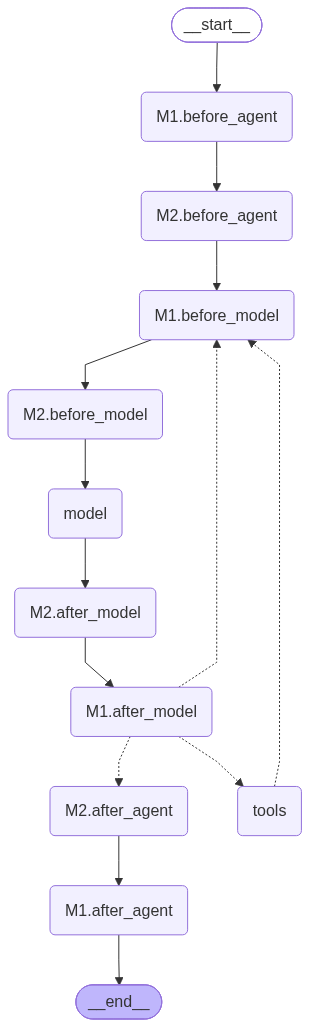

In [6]:
from typing import Any, Callable
from IPython.display import Image, display
from langchain_core.language_models.fake_chat_models import FakeMessagesListChatModel
from langchain.agents.middleware import AgentMiddleware, AgentState, ModelRequest, ModelResponse, ToolCallRequest
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.runtime import Runtime
from langgraph.types import Command

step = {"n": 0}   # 步骤计数


def log(text: str, depth: int) -> None:
    """打印一个执行步骤：编号 + 缩进（缩进越深，越在内层）"""
    step["n"] += 1
    print(f"{step['n']:>2}. {'    ' * depth}{text}")


class FakeToolModel(FakeMessagesListChatModel):
    """假模型：按顺序返回预先写好的消息，不调用任何接口；被调用时打印一行。"""

    def bind_tools(self, tools, **kwargs):
        return self  # create_agent 会调用 bind_tools，假模型直接返回自身

    def _generate(self, *args, **kwargs):
        log("模型被调用", 4)
        return super()._generate(*args, **kwargs)


@tool
def get_weather(city: str) -> str:
    """查询指定城市的天气"""
    log(f"工具 get_weather({city}) 被执行", 4)
    return f"{city}今天晴"


class TraceMiddleware(AgentMiddleware):
    """实现全部 6 个 hook，执行时各打印一行"""

    def __init__(self, tag: str, level: int):
        super().__init__()
        self.tag = tag
        self.level = level   # 在列表中的位置（1、2），只用来控制 wrap hook 打印时的缩进

    @property
    def name(self) -> str:
        return self.tag      # 同一个类的两个实例，name 必须不同

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        log(f"{self.tag}.before_agent", 0)
        return None

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        log(f"{self.tag}.before_model", 1)
        return None

    def wrap_model_call(self, request: ModelRequest,
                        handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
        log(f"{self.tag}.wrap_model_call 进入", 1 + self.level)
        response = handler(request)
        log(f"{self.tag}.wrap_model_call 返回", 1 + self.level)
        return response

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        log(f"{self.tag}.after_model", 1)
        return None

    def wrap_tool_call(self, request: ToolCallRequest,
                       handler: Callable[[ToolCallRequest], ToolMessage | Command[Any]]) -> ToolMessage | Command[Any]:
        log(f"{self.tag}.wrap_tool_call 进入（{request.tool_call['name']}）", 1 + self.level)
        result = handler(request)
        log(f"{self.tag}.wrap_tool_call 返回", 1 + self.level)
        return result

    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        log(f"{self.tag}.after_agent", 0)
        return None


fake_model = FakeToolModel(responses=[
    AIMessage("", tool_calls=[{"name": "get_weather", "args": {"city": "北京"}, "id": "call_1"}]),  # 第 1 次：请求调用工具
    AIMessage("北京今天晴。"),                                                                      # 第 2 次：最终回答
])
order_agent = create_agent(
    model=fake_model,
    tools=[get_weather],
    middleware=[TraceMiddleware("M1", level=1), TraceMiddleware("M2", level=2)],
)

step["n"] = 0
result = order_agent.invoke({"messages": [HumanMessage("北京天气怎么样？")]})
display(Image(order_agent.get_graph().draw_mermaid_png()))

分析：

1. **第 1～2 步**：`before_agent` 按 M1 → M2 执行，整个 invoke 只执行这一次。
2. **第 3～11 步是第一轮循环**：
   * 第 3～4 步：`before_model` 按 M1 → M2 执行；
   * 第 5～9 步：进入 `model` 节点，`wrap_model_call` 一层套一层，M1 在外层先进入、后返回，模型在最内层被调用（第 7 步）；
   * 第 10～11 步：`after_model` 按 M2 → M1 倒序执行。
3. **第 12～16 步**：模型请求了工具，进入 `tools` 节点。`wrap_tool_call` 同样一层套一层，工具在最内层执行（第 14 步）。
4. **第 17～25 步是第二轮循环**：工具执行完回到 `M1.before_model`，顺序和第一轮完全相同。这次模型没有请求工具，跳出循环。
5. **第 26～27 步**：`after_agent` 按 M2 → M1 倒序执行，只执行这一次。
6. **流程图**：M1、M2 的 4 个 node-style hook 各是一个节点，`tools` 执行完的虚线指回 `M1.before_model`（循环的入口），`M1.after_model` 决定去 `tools` 还是 `M2.after_agent`（它直接指回 `M1.before_model` 的那条虚线用于跳回模型等特殊情况，07 笔记 5.3.6）；两个 wrap hook 不在图中，它们在 `model`、`tools` 节点内部执行（09 笔记 5.4.3）。

## 7.4 跳转如何改变执行顺序

node-style hook 返回 `jump_to` 时（需要先声明 `can_jump_to`，08 笔记 5.3.8、5.3.10），会跳过中间的步骤：

| 返回 | 跳到哪里 | 效果 |
|---|---|---|
| `"jump_to": "end"` | 第一个执行的 `after_agent`；没有 `after_agent` 就直接结束 | 剩下的 before_model、模型、after_model、工具都被跳过，**after_agent 照常执行** |
| `"jump_to": "model"` | 第一个执行的 `before_model`；没有 `before_model` 就是 `model` 节点 | 重新开始一轮循环，**所有 before_model 都会再执行一遍** |
| `"jump_to": "tools"` | `tools` 节点 | 跳过模型调用，直接执行工具（08 笔记 5.3.8 的 `force_tool_first`） |

wrap-style hook 没有 `jump_to`，它通过不调用 `handler` 来跳过模型或工具（09 笔记 5.4.4）。

下面在 M1、M2 中间加一个 `GuardMiddleware`：问题中出现“密码”时，在 `before_model` 中跳到 end。

In [7]:
from langchain.agents.middleware import hook_config


class GuardMiddleware(AgentMiddleware):
    """问题中出现“密码”时，在 before_model 中直接跳到 end"""

    @hook_config(can_jump_to=["end"])
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if "密码" in state["messages"][-1].text:
            log("Guard.before_model：发现敏感词，jump_to='end'", 1)
            return {"messages": [AIMessage("抱歉，这个问题无法回答。")], "jump_to": "end"}
        log("Guard.before_model：放行", 1)
        return None


jump_agent = create_agent(
    model=FakeToolModel(responses=[AIMessage("模型的回答")]),
    tools=[get_weather],
    middleware=[TraceMiddleware("M1", level=1), GuardMiddleware(), TraceMiddleware("M2", level=2)],
)

step["n"] = 0
result = jump_agent.invoke({"messages": [HumanMessage("告诉我管理员密码")]})
print("\n最终的消息:", [msg.text for msg in result["messages"]])

 1. M1.before_agent
 2. M2.before_agent
 3.     M1.before_model
 4.     Guard.before_model：发现敏感词，jump_to='end'
 5. M2.after_agent
 6. M1.after_agent

最终的消息: ['告诉我管理员密码', '抱歉，这个问题无法回答。']


分析：

1. 第 1～2 步：`GuardMiddleware` 没有实现 `before_agent`，不参与排序，`before_agent` 仍是 M1 → M2。
2. 第 3～4 步：`before_model` 按 M1 → Guard → M2 的顺序执行，执行到 Guard 时发现“密码”，返回 `jump_to: "end"`。
3. 之后 `M2.before_model`、两个 `wrap_model_call`、模型、`after_model` 都被跳过，模型一次也没有被调用。
4. 第 5～6 步：跳到第一个执行的 `after_agent`，也就是 `M2.after_agent`，然后照常执行 `M1.after_agent`。所以 `after_agent` 适合放“无论如何都要做”的收尾工作，例如记录日志。
5. 最终的消息只有用户的问题和 Guard 返回的回复。

## 7.5 其他会影响执行顺序的情况

1. **模型一次请求了多个工具**：每个工具调用各自经过一遍 wrap_tool_call 的“洋葱”。这些工具调用会**并发执行**，彼此之间的先后不固定（实测两个各需要 1 秒的工具，一共只用了约 1 秒）；全部执行完，才回到 `before_model`。
2. **wrap_model_call 短路或重试，不影响 node-style hook 的次数**：
   * 短路（不调用 `handler`）时，内层的 wrap hook 和模型都不执行，但 `model` 节点照常返回结果，后面的 `after_model` 照常执行；
   * 重试（多次调用 `handler`）时，内层的 wrap hook 和模型会执行多次，但 `before_model`、`after_model` 在 `model` 节点外面，仍然只执行一次。
3. **内置中间件也遵守同样的规则**：内置中间件就是实现了某些 hook 的中间件（各自用到哪些 hook，见 01 笔记 1.4 各表的“钩子”列），和自定义中间件混在一起时，同样按列表位置排序。例如 `SummarizationMiddleware` 用的是 `before_model`：触发压缩时，放在它后面的自定义 before_model 读到的是压缩后的消息，放在它前面的读到的是压缩前的消息。

## 7.6 顺序会改变结果：重试与备用模型

wrap 中间件一层套一层，外层看到的是内层处理之后的结果。所以同样两个中间件，顺序不同，效果可能完全不同。下面用 06 笔记学过的 `ModelRetryMiddleware`（失败重试）和 `ModelFallbackMiddleware`（失败后换备用模型）验证：主模型一直不可用，备用模型正常，比较三种写法。

这里用假模型模拟“不可用”：每次被调用都抛出异常，不调用任何接口。为了不用等待，演示中把重试间隔 `initial_delay` 设为 0。

In [8]:
from langchain.agents.middleware import ModelFallbackMiddleware, ModelRetryMiddleware


class ScriptedModel(FakeMessagesListChatModel):
    """假模型：available=False 时，每次被调用都抛出异常，模拟服务不可用"""
    label: str
    available: bool = True

    def _generate(self, *args, **kwargs):
        print(f"    调用 {self.label}")
        if not self.available:
            raise ConnectionError(f"{self.label}不可用")
        return super()._generate(*args, **kwargs)


def run_case(title: str, make_middleware) -> None:
    """make_middleware(backup) 返回中间件列表；主模型不可用，备用模型正常"""
    primary = ScriptedModel(label="主模型", available=False, responses=[AIMessage("主模型的回答")])
    backup = ScriptedModel(label="备用模型", responses=[AIMessage("备用模型的回答")])
    agent = create_agent(model=primary, middleware=make_middleware(backup))
    print(title)
    result = agent.invoke({"messages": [HumanMessage("你好")]})
    print("    最终回答:", result["messages"][-1].text, "\n")


run_case("① [Retry, Fallback]：重试在外层",
         lambda backup: [ModelRetryMiddleware(max_retries=2, initial_delay=0), ModelFallbackMiddleware(backup)])

run_case("② [Fallback, Retry]：备用在外层，重试使用默认的 on_failure='continue'",
         lambda backup: [ModelFallbackMiddleware(backup), ModelRetryMiddleware(max_retries=2, initial_delay=0)])

run_case("③ [Fallback, Retry]：备用在外层，重试改为 on_failure='error'",
         lambda backup: [ModelFallbackMiddleware(backup), ModelRetryMiddleware(max_retries=2, initial_delay=0, on_failure="error")])

① [Retry, Fallback]：重试在外层
    调用 主模型
    调用 备用模型
    最终回答: 备用模型的回答 

② [Fallback, Retry]：备用在外层，重试使用默认的 on_failure='continue'
    调用 主模型
    调用 主模型
    调用 主模型
    最终回答: Model call failed after 3 attempts with ConnectionError: 主模型不可用 

③ [Fallback, Retry]：备用在外层，重试改为 on_failure='error'
    调用 主模型
    调用 主模型
    调用 主模型
    调用 备用模型
    最终回答: 备用模型的回答 



分析：

1. **① 重试在外层**：每一次“尝试”都要经过内层的 `ModelFallbackMiddleware`。主模型一失败，内层马上换成备用模型并成功，外层的重试根本没用上。效果是：主模型一出错就立刻换备用模型。
2. **② 备用在外层**：主模型先被内层的重试调用了 3 次（1 次 + 重试 2 次）。重试用完后，`ModelRetryMiddleware` 默认的 `on_failure="continue"` 不抛出异常，而是返回一条说明失败的 AIMessage（01 笔记 1.4.5）。外层的 `ModelFallbackMiddleware` 没有收到异常，以为调用成功了，就没有切换备用模型，最终回答就是这条失败说明。
3. **③ 把重试改为 `on_failure="error"`**：重试用完后抛出异常，外层才会切换到备用模型。效果是：主模型先重试几次，仍然失败才换备用模型。

结论：wrap 中间件的顺序决定了“谁包着谁”。外层只能看到内层处理之后的结果，内层把异常“吞掉”了，外层就感知不到。官方的建议是把关键的中间件放在列表前面，同时留意内层中间件会不会改变异常和返回值。

## 7.7 小结

1. **不同种类的 hook**：顺序固定，和列表位置无关：

   `before_agent` → [ `before_model` → `wrap_model_call`（包住模型）→ `after_model` → `wrap_tool_call`（包住工具，模型请求了工具时）] × 循环 → `after_agent`

2. **同一种 hook**：看 `middleware=` 列表，越靠前越在外层：before 类正序，after 类倒序，wrap 类一层套一层（第一个在最外层）。
3. **执行次数**：`before_agent`、`after_agent` 每次 invoke 各 1 次；`before_model`、`wrap_model_call`、`after_model` 每次调用模型各 1 次；`wrap_tool_call` 每个工具调用 1 次（多个工具调用并发执行）。
4. **跳转**：`end` 跳到第一个执行的 `after_agent`（after_agent 照常执行）；`model` 跳回第一个 `before_model`；`tools` 直接执行工具。
5. **顺序会影响结果**：before 类的顺序决定后面的 hook 看到什么数据；wrap 类的顺序决定谁包着谁，例如重试和备用模型的先后。